# Main — Combined Tip 1 + Tip 2 Features

Toggle `USE_TIP1` / `USE_TIP2` to include or exclude each feature set.

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

import lightgbm as lgbm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

import tip1_features
import tip2_features
import tip3_features

### Config — toggle feature sets here

In [13]:
USE_TIP1 = True   # cross-sectional normalization, ranks, date-context
USE_TIP2 = True   # momentum sums, acceleration, EWMA, standardized reversal
USE_TIP3 = True   # distribution shape, streaks, drawdown, vol interactions

### Load data

In [14]:
X_train = pd.read_csv('../data/X_train.csv', index_col='ROW_ID')
X_test  = pd.read_csv('../data/X_test.csv',  index_col='ROW_ID')
y_train = pd.read_csv('../data/y_train.csv', index_col='ROW_ID')
sample_submission = pd.read_csv('../submission/sample_submission.csv', index_col='ROW_ID')

RET_cols = [f'RET_{i}'           for i in range(1, 21)]
VOL_cols = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]

### Feature engineering

#### Benchmark features (always included)

In [15]:
def add_benchmark_features(df):
    for i in [3, 5, 10, 15, 20]:
        df[f'AVERAGE_PERF_{i}'] = df[RET_cols[:i]].mean(axis=1)
        df[f'ALLOCATIONS_AVERAGE_PERF_{i}'] = df.groupby('TS')[f'AVERAGE_PERF_{i}'].transform('mean')
    df['STD_PERF_20'] = df[RET_cols].std(axis=1)
    df['ALLOCATIONS_STD_PERF_20'] = df.groupby('TS')['STD_PERF_20'].transform('mean')
    return df

X_train = add_benchmark_features(X_train)
X_test  = add_benchmark_features(X_test)

benchmark_features = (
    RET_cols + VOL_cols + ['MEDIAN_DAILY_TURNOVER']
    + [f'AVERAGE_PERF_{i}'             for i in [3, 5, 10, 15, 20]]
    + [f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3, 5, 10, 15, 20]]
    + ['STD_PERF_20', 'ALLOCATIONS_STD_PERF_20']
)

#### Tip 1 and Tip 2 (controlled by config flags above)

In [16]:
features = list(benchmark_features)

if USE_TIP1:
    X_train, f1 = tip1_features.add_features(X_train, RET_cols, VOL_cols)
    X_test,  _  = tip1_features.add_features(X_test,  RET_cols, VOL_cols)
    features += f1
    print(f"Tip 1: +{len(f1)} features")

if USE_TIP2:
    X_train, f2 = tip2_features.add_features(X_train, RET_cols, VOL_cols)
    X_test,  _  = tip2_features.add_features(X_test,  RET_cols, VOL_cols)
    features += f2
    print(f"Tip 2: +{len(f2)} features")

if USE_TIP3:
    X_train, f3 = tip3_features.add_features(X_train, RET_cols, VOL_cols)
    X_test,  _  = tip3_features.add_features(X_test,  RET_cols, VOL_cols)
    features += f3
    print(f"Tip 3: +{len(f3)} features")

print(f"Total features: {len(features)}")

/Users/tungyuenlok/Desktop/Asset-Allocation-Performance-forecasting/code/tip1_features.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name] = df.groupby('TS')[src].rank(pct=True)
/Users/tungyuenlok/Desktop/Asset-Allocation-Performance-forecasting/code/tip1_features.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[src] = df[vol_cols[:i]].mean(axis=1)
/Users/tungyuenlok/Desktop/Asset-Allocation-Performance-forecasting/code/tip1_features.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the

Tip 1: +52 features


/Users/tungyuenlok/Desktop/Asset-Allocation-Performance-forecasting/code/tip2_features.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = df[ret_cols[:horizon]].sum(axis=1)
/Users/tungyuenlok/Desktop/Asset-Allocation-Performance-forecasting/code/tip2_features.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = df[ret_cols[:horizon]].sum(axis=1)
/Users/tungyuenlok/Desktop/Asset-Allocation-Performance-forecasting/code/tip2_features.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually t

Tip 2: +17 features


/Users/tungyuenlok/Desktop/Asset-Allocation-Performance-forecasting/code/tip3_features.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['RET_SKEW'] = df[ret_cols].skew(axis=1)
/Users/tungyuenlok/Desktop/Asset-Allocation-Performance-forecasting/code/tip3_features.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['FRAC_POS_20'] = (rets > 0).mean(axis=1)
/Users/tungyuenlok/Desktop/Asset-Allocation-Performance-forecasting/code/tip3_features.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

Tip 3: +18 features
Total features: 140


/Users/tungyuenlok/Desktop/Asset-Allocation-Performance-forecasting/code/tip3_features.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['LONGEST_DOWN_STREAK'] = np.apply_along_axis(_max_consec, 1, down)
/Users/tungyuenlok/Desktop/Asset-Allocation-Performance-forecasting/code/tip3_features.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['POS_LAST_3'] = (rets[:, :3] > 0).sum(axis=1)
/Users/tungyuenlok/Desktop/Asset-Allocation-Performance-forecasting/code/tip3_features.py:65: PerformanceWarning: DataFrame is highly f

### LightGBM — 8-fold cross-validation on dates

In [17]:
lgbm_params = {
    "objective":     "mse",
    "metric":        "mse",
    "num_threads":   50,
    "seed":          42,
    "verbosity":     -1,
    "learning_rate": 1e-2,
    "max_depth":     3,
}
NUM_BOOST_ROUND = 500

train_dates = X_train['TS'].unique()
scores, models = [], []

splits = KFold(n_splits=8, shuffle=True, random_state=0).split(train_dates)

for fold, (tr_idx, val_idx) in enumerate(splits):
    tr_mask  = X_train['TS'].isin(train_dates[tr_idx])
    val_mask = X_train['TS'].isin(train_dates[val_idx])

    X_tr  = X_train.loc[tr_mask,  features].fillna(0)
    y_tr  = y_train.loc[tr_mask,  'target']
    X_val = X_train.loc[val_mask, features].fillna(0)
    y_val = y_train.loc[val_mask, 'target']

    model = lgbm.train(lgbm_params,
                       lgbm.Dataset(X_tr, label=y_tr.values),
                       num_boost_round=NUM_BOOST_ROUND)

    preds = model.predict(X_val.values, num_threads=lgbm_params['num_threads'])
    acc   = accuracy_score((y_val > 0).astype(int), (preds > 0).astype(int))

    models.append(model)
    scores.append(acc)
    print(f"Fold {fold+1} — Accuracy: {acc*100:.2f}%")

mean = np.mean(scores) * 100
std  = np.std(scores)  * 100
print(f"\nAccuracy: {mean:.2f}% ± {std:.2f}%  [{mean-std:.2f} ; {mean+std:.2f}]")

Fold 1 — Accuracy: 52.30%
Fold 2 — Accuracy: 52.26%
Fold 3 — Accuracy: 52.09%
Fold 4 — Accuracy: 52.26%
Fold 5 — Accuracy: 51.75%
Fold 6 — Accuracy: 52.37%
Fold 7 — Accuracy: 52.46%
Fold 8 — Accuracy: 52.11%

Accuracy: 52.20% ± 0.21%  [51.99 ; 52.41]


### Feature importance (top 30 by gain)

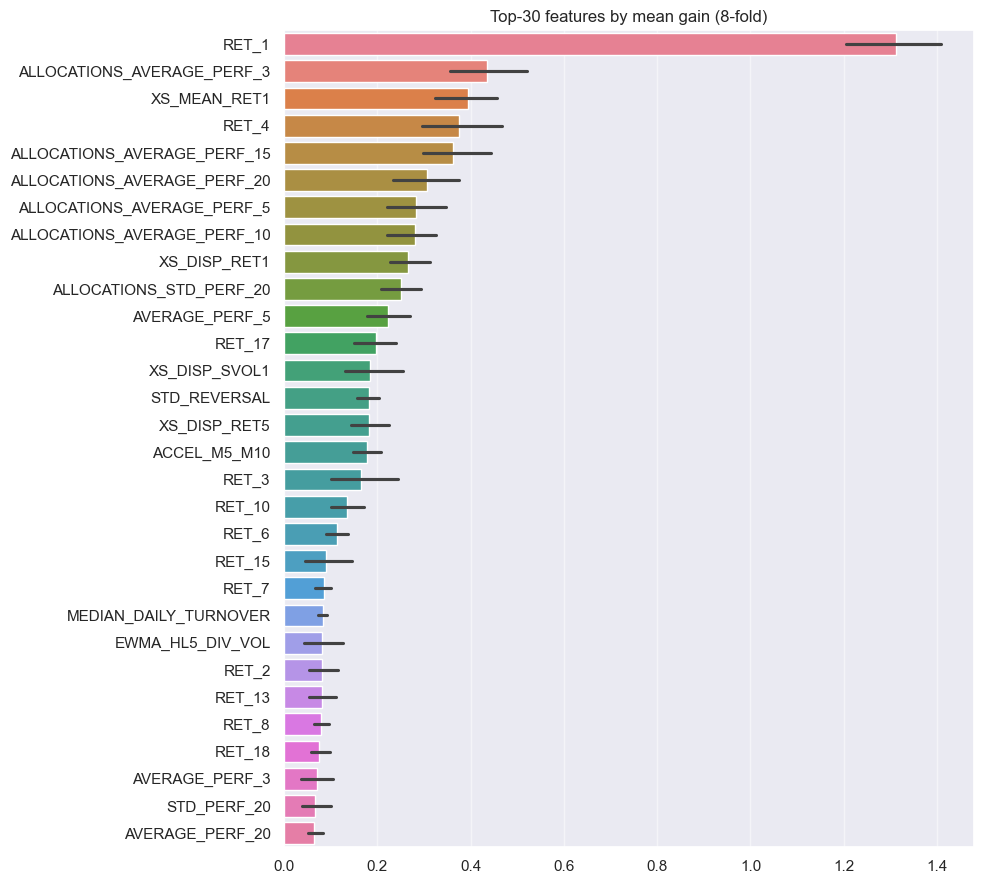

In [18]:
importances = pd.DataFrame(
    [m.feature_importance(importance_type='gain') for m in models],
    columns=features
)
top30 = importances.mean().sort_values(ascending=False).head(30).index

plt.figure(figsize=(10, 9))
sns.barplot(data=importances[top30], orient='h',
            order=importances[top30].mean().sort_values(ascending=False).index)
plt.title("Top-30 features by mean gain (8-fold)")
plt.tight_layout()
plt.show()

### Final model + submission

In [19]:
final_model = lgbm.train(
    lgbm_params,
    lgbm.Dataset(X_train[features].fillna(0), label=y_train['target'].values),
    num_boost_round=NUM_BOOST_ROUND
)

test_preds = final_model.predict(X_test[features].fillna(0).values)
submission = pd.DataFrame(
    (test_preds > 0).astype(int),
    index=sample_submission.index,
    columns=['TARGET']
)

tips_tag = '_'.join(
    t for t, flag in [('tip1', USE_TIP1), ('tip2', USE_TIP2), ('tip3', USE_TIP3)] if flag
)
fname = f'preds_{tips_tag}.csv'
submission.to_csv(fname)
print(f"Saved {fname}")
submission['TARGET'].value_counts()

Saved preds_tip1_tip2_tip3.csv


TARGET
1    18366
0    13504
Name: count, dtype: int64